In [ ]:
/content/drive/MyDrive/Colab Notebooks/titanic.csv

In [50]:
import pandas as pd
import numpy as np

from sklearn import datasets
import pandas as pd
from sklearn.model_selection import train_test_split # 데이터를 train, test로 나누는 데 사용됨
from sklearn.preprocessing import StandardScaler # 데이터를 표준화하는 데 사용됨
from sklearn.tree import DecisionTreeClassifier # 결정 트리 모델을 학습시키는 데 사용됨
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트
from sklearn.svm import SVC # 서포트 벡터 머신
from sklearn.linear_model import LogisticRegression # 로지스틱 회귀 모델
from sklearn.metrics import accuracy_score # 모델의 예측 성능 평가
# CSV 파일 읽기
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/titanic.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [55]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [59]:
X = df.drop(['Survived', 'Name', 'Ticket', 'Cabin'], axis=1)
y = df['Survived']

# 결측치 처리

X['Age'] = X['Age'].fillna(X['Age'].mean())
X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])

# 문자열 → 숫자 변환
X = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

In [60]:
clf_lr = LogisticRegression(max_iter=1000)

clf_lr.fit(X_train, y_train)

pred_lr = clf_lr.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print(confusion_matrix(y_test, pred_lr))

Logistic Regression
Accuracy: 0.7937219730941704
[[116  23]
 [ 23  61]]


In [35]:
clf_svm = SVC()

clf_svm.fit(X_train, y_train)

pred_svm = clf_svm.predict(X_test)

print("\nSVM")
print("Accuracy:", accuracy_score(y_test, pred_svm))
print(confusion_matrix(y_test, pred_svm))


SVM
Accuracy: 0.6636771300448431
[[138   1]
 [ 74  10]]


In [42]:

clf_dt = DecisionTreeClassifier()

clf_dt.fit(X_train, y_train)

pred_dt = clf_dt.predict(X_test)

print("\nDecision Tree")
print("Accuracy:", accuracy_score(y_test, pred_dt))
print(confusion_matrix(y_test, pred_dt))


Decision Tree
Accuracy: 0.7892376681614349
[[115  24]
 [ 23  61]]


In [52]:
from sklearn.ensemble import RandomForestClassifier # 랜덤 포레스트
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.8341


In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱근오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(ly_preds, y_test))

평균제곱근오차 0.1388447220096706
평균제곱근오차 0.1388447220096706
평균제곱근오차 0.13884472200967057


<>:16: SyntaxWarning: invalid decimal literal
<>:16: SyntaxWarning: invalid decimal literal
/tmp/ipykernel_8147/3032514812.py:16: SyntaxWarning: invalid decimal literal
  sum_square_error = sum((a - p) ** 2for a, p in zip(actual, predicted))


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


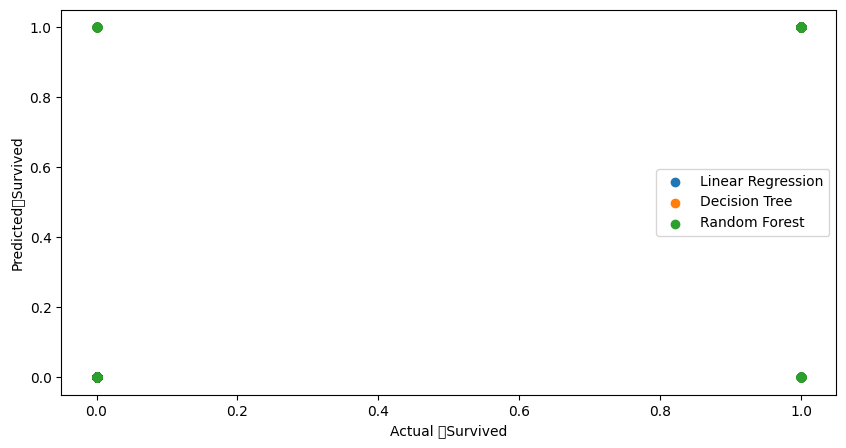

In [54]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(y_test, pred_lr, label='Linear Regression')
plt.scatter(y_test, pred_dt, label='Decision Tree')
plt.scatter(y_test, rf_pred, label='Random Forest')

plt.xlabel("Actual 	Survived")
plt.ylabel("Predicted	Survived")
plt.legend()

plt.show()